In [1]:
# --- repo-root prelude (added 2026-08-02 with the folder reorganisation) ---
# This notebook lives in a subfolder but every path below is relative to the REPO ROOT,
# and `import features` needs the root on sys.path. Walk up until we find paths.py, so it
# works whether Jupyter was started here or at the root. Idempotent.
import os, sys
while not os.path.exists('paths.py') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
import paths  # noqa: F401  - also puts pipeline/ + models/ on sys.path
# --- end prelude ---


# Margin model — predicting HOW MUCH a candidate wins by

**Completely separate from `model.ipynb`** (the win/lose classifier): separate notebook,
separate tuned hyperparameters, separate saved artifact (`data/margin_model_xgb.json`).

**Why this model exists:** for win/lose, the poll leader is already right ~87% of the time —
polls are the ceiling. But polls do NOT already contain *how far off they themselves will be*.
Predicting the actual victory margin is where fundamentals (incumbency, prior results,
national environment, economy) get a fair test.

**Target:** `margin_actual` = candidate's actual vote % minus the best opponent's actual
vote % (positive = won by that much). Same leak-free features from `features.py`; the
`vote_pct` label is used ONLY as the target, never as a feature.

**Validation:** identical nested scheme to the win model — tune on 1998–2016, honest
leave-one-cycle-out evaluation on 2018–2024.

In [2]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

from cycles import CYCLES, TUNE_CYCLES, EVAL_CYCLES, natl_env
import features as F
from macro_features import build_macro

pd.set_option('display.max_columns', 60)
print('xgboost', xgb.__version__)

xgboost 3.2.0


In [3]:
d = pd.read_csv('polls_long_with_results.csv', low_memory=False)
# DEAD MATCHUPS - same filter model.ipynb applies (added 2026-08-06). A question whose
# opponent never made the ballot measured the surviving candidate against someone who
# never ran; keep the two notebooks in step or their poll sets silently diverge.
_gen = d[d['stage'] == 'general']
_q = _gen.groupby(['race_id', 'question_id'])['has_result'].agg(['sum', 'size'])
_dead = set(_q[(_q['sum'] > 0) & (_q['sum'] < _q['size'])].index)
_key = list(zip(d['race_id'], d['question_id']))
_drop = pd.Series([k in _dead for k in _key], index=d.index) & (d['stage'] == 'general')
print(f'dead-matchup rows dropped from training: {int(_drop.sum())} ({len(_dead)} questions)')
d = d[~_drop]
d = d[d['has_result'] == 1].copy()
d = F.prepare_polls(d)
d = d[d['year'].isin(CYCLES)].copy()
d['race_id'] = (d['year'].astype(str) + '_' + d['state'] + '_' + d['office']
                + d['district'].radd('-').where(d['district'] != '', ''))


dead-matchup rows dropped from training: 1570 (666 questions)


In [4]:
FUNDS = F.load_fundamentals()
NATL_ENV = natl_env()
FEC = F.load_fec(extended=True)
BIAS = F.compute_bias_priors(d)
macro = build_macro()
MACRO_FEATS = sorted({k for cyc in macro for k in macro[cyc]})
# bio_office_level SHIPPED 2026-07-29 (margin MAE -0.071 on 100%-covered leak-free data) - see
# the win model's BASE-build cell for the full flip-the-verdict story. Pass candidate_bios=True
# here AND to build_candidate_table below AND at serve time (predict_margin.py).
FEATURES = F.feature_list(MACRO_FEATS, fund=True, candidate_bios=True)
print('features:', len(FEATURES), '| macro:', len(MACRO_FEATS))

features: 187 | macro: 144


In [5]:
# candidate table + leak-free folds (same construction as the win model)
BIOS = F.load_candidate_bios()
BASE = F.build_candidate_table(d, macro, NATL_ENV, FUNDS, house_train_years=CYCLES, fec=FEC,
                               bias_priors=BIAS, candidate_bios=BIOS)

def add_margin_target(c):
    c = c.copy()
    mx = c.groupby('race_id')['vote_pct'].transform('max')
    def second(s):
        return s.nlargest(2).iloc[-1] if len(s) > 1 else np.nan
    m2 = c.groupby('race_id')['vote_pct'].transform(second)
    best_other = np.where(c['vote_pct'] >= mx, m2, mx)
    c['margin_actual'] = c['vote_pct'] - best_other
    return c[c['margin_actual'].notna()]

def fold_table(test_year):
    house = F.compute_house_effect(d, [y for y in CYCLES if y != test_year])
    adj = F.candidate_poll_adj(d, house).rename('poll_adj').reset_index()
    c = BASE.drop(columns='poll_adj').merge(adj, on=['race_id', 'cand_key'], how='left')
    return add_margin_target(c)

FOLDS = {ty: fold_table(ty) for ty in CYCLES}
cand = FOLDS[2024]

# sanity: sign of actual margin must almost always agree with the win label
agree = ((cand['margin_actual'] > 0).astype(int) == cand['won']).mean()
print('candidate rows with margin target:', len(cand))
print('sign(margin) agrees with won:', round(agree, 4))
print('bio_office_level coverage:', round(cand['bio_office_level'].notna().mean(), 3))
# ~3-4% legit disagreement: RCV races (AK) and runoff states, where the
# first-round vote leader can lose. The margin target is still well-defined.
assert agree > 0.95, 'margin target inconsistent with win labels'
print('margin distribution:', cand['margin_actual'].describe().round(1).to_dict())

candidate rows with margin target: 4400
sign(margin) agrees with won: 0.9723
bio_office_level coverage: 0.998
margin distribution: {'count': 4400.0, 'mean': -5.7, 'std': 25.9, 'min': -76.9, '25%': -19.1, '50%': -2.6, '75%': 10.4, 'max': 76.9}


In [6]:
# ---- nested tuning: XGBRegressor, scored by MAE over the 1998-2016 cycles ----
import itertools, random

def cv_mae(params, test_cycles):
    maes = []
    for ty in test_cycles:
        c = FOLDS[ty]
        tr = c[c['year'] != ty]; te = c[c['year'] == ty]
        m = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **params)
        m.fit(tr[FEATURES], tr['margin_actual'])
        maes.append(mean_absolute_error(te['margin_actual'], m.predict(te[FEATURES])))
    return float(np.mean(maes))

GRID = dict(max_depth=[2, 3], learning_rate=[0.02, 0.03, 0.05],
            n_estimators=[200, 400], min_child_weight=[8, 15, 30],
            subsample=[0.6, 0.8, 1.0], colsample_bytree=[0.4, 0.6, 1.0],
            reg_lambda=[1, 5, 20], reg_alpha=[0, 1])
keys = list(GRID)
combos = list(itertools.product(*[GRID[k] for k in keys]))
random.seed(0); random.shuffle(combos); combos = combos[:120]

best = None
for combo in combos:
    p = dict(zip(keys, combo))
    mae = cv_mae(p, TUNE_CYCLES)
    if best is None or mae < best[0]:
        best = (mae, p)

XGBR_PARAMS = dict(best[1], objective='reg:squarederror', random_state=42)
print(f'best TUNE-cycle MAE (1998-2016): {best[0]:.3f} pts')
print('XGBR_PARAMS =', best[1])

best TUNE-cycle MAE (1998-2016): 7.176 pts
XGBR_PARAMS = {'max_depth': 3, 'learning_rate': 0.02, 'n_estimators': 400, 'min_child_weight': 8, 'subsample': 0.6, 'colsample_bytree': 0.4, 'reg_lambda': 1, 'reg_alpha': 1}


In [7]:
# ---- PRIMARY HONEST EVAL - EXPANDING-WINDOW on 2018-2024: each fold trains strictly
# on cycles BEFORE the test cycle (true prospective; tuner never saw these cycles).
# NOTE the 2018 fold only has 10 training cycles and is the weak one (MAE ~10 vs ~6
# later) - the 2026-relevant fold is 2024 (13 cycles), where expanding == LOCO.
# Baselines retrain per-fold on the same expanding window (apples-to-apples). ----
# Baselines:
#   raw poll margin      : predicted margin = avg_margin_over_time (the polls' own answer)
#   calibrated poll marg : linear fit  margin_actual ~ avg_margin_over_time  on train cycles
rows, preds = [], {}
for ty in EVAL_CYCLES:
    c = FOLDS[ty]
    tr = c[c['year'] < ty]; te = c[c['year'] == ty].copy()

    m = xgb.XGBRegressor(**XGBR_PARAMS)
    m.fit(tr[FEATURES], tr['margin_actual'])
    te['pred_model'] = m.predict(te[FEATURES])

    te['pred_poll'] = te['avg_margin_over_time']
    fit_tr = tr.dropna(subset=['avg_margin_over_time'])
    lin = LinearRegression().fit(fit_tr[['avg_margin_over_time']], fit_tr['margin_actual'])
    x = te[['avg_margin_over_time']].fillna(0.0)
    te['pred_lin'] = lin.predict(x)

    def acc(col):
        pick = te.loc[te.groupby('race_id')[col].idxmax()]
        return pick['won'].mean()
    rows.append(dict(
        cycle=ty, n=len(te),
        MAE_model=mean_absolute_error(te['margin_actual'], te['pred_model']),
        MAE_poll=mean_absolute_error(te.dropna(subset=['pred_poll'])['margin_actual'],
                                     te['pred_poll'].dropna()),
        MAE_lin=mean_absolute_error(te['margin_actual'], te['pred_lin']),
        R2_model=r2_score(te['margin_actual'], te['pred_model']),
        acc_model=acc('pred_model'), acc_poll=acc('poll_avg'),
    ))
    preds[ty] = te

ev = pd.DataFrame(rows).set_index('cycle')
print('=== PRIMARY honest margin eval (EXPANDING-WINDOW 2018-2024), margins in percentage points ===')
print(ev.round(3).to_string())
print('\nMEAN:')
print(ev.mean().round(3).to_string())
print('\nMAE_model < MAE_lin < MAE_poll would mean features add real margin signal')

=== PRIMARY honest margin eval (EXPANDING-WINDOW 2018-2024), margins in percentage points ===
         n  MAE_model  MAE_poll  MAE_lin  R2_model  acc_model  acc_poll
cycle                                                                  
2018   633      9.389     8.014    8.715     0.796      0.863     0.885
2020   389      6.799     8.017    8.015     0.863      0.818     0.831
2022   475      6.169     8.036    7.760     0.881      0.890     0.879
2024   339      5.772     6.982    6.675     0.893      0.871     0.879

MEAN:
n            459.000
MAE_model      7.032
MAE_poll       7.762
MAE_lin        7.791
R2_model       0.858
acc_model      0.861
acc_poll       0.868

MAE_model < MAE_lin < MAE_poll would mean features add real margin signal


In [8]:
# COMPANION eval - LOCO (train on all other cycles INCLUDING FUTURE ones): kept only
# to monitor the optimism gap vs the primary expanding-window eval above. Measured
# 2026-07-14: gap = 1.0 MAE pt, entirely from the 2018 fold (10 train cycles);
# 2020/2022/2024 converge.
ew_rows = []
for ty in EVAL_CYCLES:
    c = FOLDS[ty]
    tr = c[c['year'] != ty]; te = c[c['year'] == ty].copy()
    m = xgb.XGBRegressor(**XGBR_PARAMS)
    m.fit(tr[FEATURES], tr['margin_actual'])
    te['pred_loco'] = m.predict(te[FEATURES])
    pick = te.loc[te.groupby('race_id')['pred_loco'].idxmax()]
    ew_rows.append(dict(
        cycle=ty, n_train_cycles=tr['year'].nunique(),
        MAE=mean_absolute_error(te['margin_actual'], te['pred_loco']),
        R2=r2_score(te['margin_actual'], te['pred_loco']),
        race_acc=pick['won'].mean(),
    ))
loco = pd.DataFrame(ew_rows).set_index('cycle')
print('=== companion eval: LOCO (trains on future cycles; headline is the expanding-window table above) ===')
print(loco.round(3).to_string())
print()
print('LOCO MAE:', round(loco['MAE'].mean(), 3),
      '| PRIMARY expanding-window MAE:', round(ev['MAE_model'].mean(), 3),
      '| LOCO optimism:', round(ev['MAE_model'].mean() - loco['MAE'].mean(), 3), 'pts (driven by the 2018 fold)')


=== companion eval: LOCO (trains on future cycles; headline is the expanding-window table above) ===
       n_train_cycles    MAE     R2  race_acc
cycle                                        
2018               13  6.303  0.870     0.859
2020               13  6.691  0.868     0.818
2022               13  6.154  0.883     0.855
2024               13  5.772  0.893     0.871

LOCO MAE: 6.23 | PRIMARY expanding-window MAE: 7.032 | LOCO optimism: 0.802 pts (driven by the 2018 fold)


In [9]:
# where does the margin model win/lose vs the calibrated poll baseline?
allp = pd.concat(preds.values())
allp['err_model'] = (allp['pred_model'] - allp['margin_actual']).abs()
allp['err_lin']   = (allp['pred_lin']   - allp['margin_actual']).abs()
by_office = allp.groupby('office')[['err_model', 'err_lin']].mean().round(2)
print('MAE by office (model vs calibrated poll):')
print(by_office.to_string())
close = allp[allp['abs_gap'] < 5]
print('\nclose races only (polled gap < 5):')
print(close[['err_model', 'err_lin']].mean().round(2).to_string())

MAE by office (model vs calibrated poll):
          err_model  err_lin
office                      
Governor       7.64     8.32
House          7.55     8.01
Senate         6.55     7.47

close races only (polled gap < 5):
err_model    6.73
err_lin      7.07


wrote models/poll/margin_feature_importance.csv


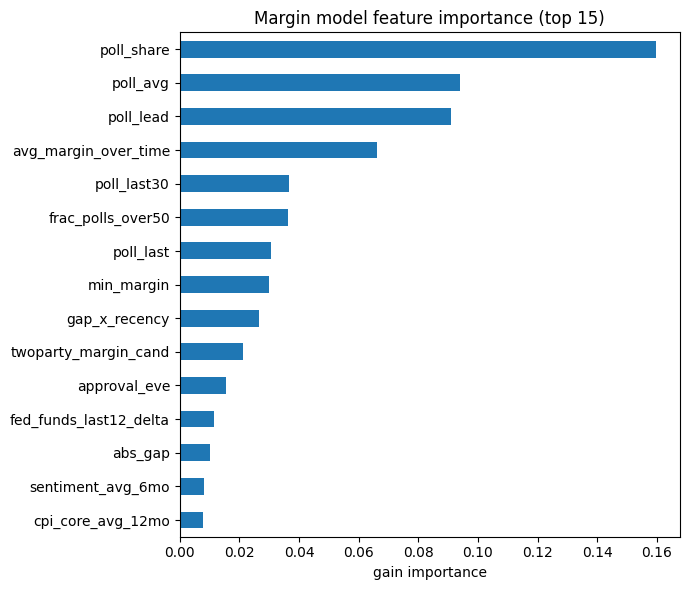

poll_share                0.1598
poll_avg                  0.0941
poll_lead                 0.0909
avg_margin_over_time      0.0662
poll_last30               0.0366
frac_polls_over50         0.0365
poll_last                 0.0308
min_margin                0.0298
gap_x_recency             0.0267
twoparty_margin_cand      0.0211
approval_eve              0.0155
fed_funds_last12_delta    0.0115
abs_gap                   0.0100
sentiment_avg_6mo         0.0082
cpi_core_avg_12mo         0.0078
dtype: float32

In [10]:
m_all = xgb.XGBRegressor(**XGBR_PARAMS)
train_all = add_margin_target(BASE)
m_all.fit(train_all[FEATURES], train_all['margin_actual'])

imp = pd.Series(m_all.feature_importances_, index=FEATURES).sort_values(ascending=False)
imp_df = imp.rename('gain_importance').reset_index().rename(columns={'index': 'feature'})
imp_df['rank'] = range(1, len(imp_df) + 1)
imp_df.to_csv('models/poll/margin_feature_importance.csv', index=False)  # beside the model (2026-08-02)
print('wrote models/poll/margin_feature_importance.csv')

top15 = imp.head(15).sort_values()
ax = top15.plot.barh(figsize=(7, 6), title='Margin model feature importance (top 15)')
ax.set_xlabel('gain importance')
plt.tight_layout(); plt.show()
imp.head(15).round(4)

In [11]:
# ---- PRODUCTION artifact (separate from the win model's) ----
import json
m_all.save_model('data/margin_model_xgb.json')
with open('data/margin_model_features.json', 'w') as f:
    json.dump({'features': FEATURES, 'macro_feats': MACRO_FEATS,
               'target': 'margin_actual (own vote_pct minus best opponent, pct points)',
               'trained_on_cycles': sorted(train_all['year'].unique().tolist()),
               'xgb_params': {k: v for k, v in XGBR_PARAMS.items()}}, f, indent=1)
print('saved data/margin_model_xgb.json + data/margin_model_features.json',
      f'({len(train_all)} rows, {train_all["race_id"].nunique()} races)')

saved data/margin_model_xgb.json + data/margin_model_features.json (4400 rows, 1962 races)


## Notes

- The interesting comparison is **MAE_model vs MAE_lin**: the linear baseline already fixes
  any constant bias/scale in the polled margin, so beating it means the *other* features
  (incumbency, prior margin, national environment, economy) carry real margin information.
- `acc_model` vs `acc_poll` shows whether better margins also flip winner calls.
- **Never** feed `vote_pct` / `margin_actual` / `race_winning_pct` as features — they are
  the outcome. The label flows through `features.py` as a passenger column only.
- Prediction on live races: `predict_margin.py` (same polling-agg feed as `predict.py`).